In [14]:
import pandas as pd
import numpy as np
import datetime
from matplotlib import pyplot as plt
import metpy.calc as mpcalc
from metpy.cbook import get_test_data
from metpy.plots import add_metpy_logo, SkewT
from metpy.units import units
import metpy.constants as mpconst
from scipy.signal import argrelextrema
from scipy.signal import find_peaks
from matplotlib  import cm

# Dataset 1: The measurements from the weather balloons

## Data Processing

When we obtain raw data, it's often not in the ideal format for analysis.  
In this section, we process the data to make it easier to work with. This includes:

* Renaming columns and removing any unnecessary fields  
* Converting time strings (just plain text) into time objects (Python recognizes as actual dates and times)
* Adjusting time from UTC to local time  


In [15]:
def convert_utc_times(times):
    """
    Convert a list of time strings (in UTC) to full datetime objects in UTC.
    
    Times from 19:00:00 and later are treated as March 24,
    and earlier times as March 25.
    """
    datetime_strings = []
    for t in times:
        hour = int(t.split(':')[0])
        if hour >= 19:
            datetime_strings.append('2024-03-24 ' + t)
        else:
            datetime_strings.append('2024-03-25 ' + t)

    # Convert to datetime objects (still in UTC)
    datetimes_utc = pd.to_datetime(datetime_strings, format='%Y-%m-%d %H:%M:%S')
    
    return datetimes_utc

In [16]:
new_column_names = {
    # Format is 
    # Old name : new name
    'UTC time': 'utc_time',
    ' Altitude (m MSL)': 'height_msl_m',
    ' Altitude (m AGL)': 'height_agl_m',
    ' Pressure (Pascal)': 'pressure',
    ' Speed (m/s)': 'horizontal_speed_mps',
    ' Heading (degrees)': 'heading_deg',
    ' Temperature (C)': 'temperature',
    ' Relative humidity (%)': 'rh',
    ' Internal temperature (C)': 'internal_temp_c',
    ' Latitude': 'latitude',
    ' Longitude': 'longitude',
    ' Rise speed (m/s)': 'vertical_speed_mps',
}

In [17]:
# data
PATH ='2026-03-31_0720.raw_history.csv'



In [18]:

data = pd.read_csv(PATH)



In [19]:
data

,UTC time,Altitude (m MSL),Altitude (m AGL),Pressure (Pascal),Speed (m/s),Heading (degrees),Temperature (C),Relative humidity (%),Internal temperature (C),Latitude,Longitude,Rise speed (m/s)
0,20:06:57,55,3,99968,,,18.70,86.15,,,,
1,20:06:59,55,3,99968,,,18.63,85.95,,,,
2,20:07:00,55,3,99969,,,18.58,86.00,,,,
3,20:07:01,55,3,99970,,,18.50,85.65,,,,
4,20:07:02,55,3,99971,,,18.40,85.10,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...
15025,00:50:34,49,-2,100042,1.10,119.60,22.28,69.60,,,,-0.1
15026,00:50:35,48,-3,100050,0.70,95.80,22.29,69.70,,-37.794482,144.961443,-0.1
15027,00:50:36,49,-2,100039,0.55,96.90,22.38,69.30,,,,0
15028,00:50:37,50,-1,100028,0.55,96.90,22.32,68.70,,,,0.1


In [20]:
data = (data
         .rename(columns=new_column_names) # Rename the columns
         .drop(columns=['latitude', 'longitude', 'internal_temp_c']) # Remove these columns
        )

data = (data
         .rename(columns=new_column_names) # Rename the columns
         .drop(columns=['latitude', 'longitude', 'internal_temp_c']) # Remove these columns
        )

In [21]:
data.head()

,utc_time,height_msl_m,height_agl_m,pressure,horizontal_speed_mps,heading_deg,temperature,rh,vertical_speed_mps
0,20:12:01,75,9,100728,,,15.60,67.35,
1,20:12:02,75,9,100729,,,15.58,67.30,
2,20:12:03,75,9,100730,,,15.57,67.25,
3,20:12:04,75,9,100728,,,15.55,67.20,
4,20:12:05,75,9,100727,,,15.54,67.20,


In [22]:
data

,utc_time,height_msl_m,height_agl_m,pressure,horizontal_speed_mps,heading_deg,temperature,rh,vertical_speed_mps
0,20:06:57,55,3,99968,,,18.70,86.15,
1,20:06:59,55,3,99968,,,18.63,85.95,
2,20:07:00,55,3,99969,,,18.58,86.00,
3,20:07:01,55,3,99970,,,18.50,85.65,
4,20:07:02,55,3,99971,,,18.40,85.10,
...,...,...,...,...,...,...,...,...,...
15025,00:50:34,49,-2,100042,1.10,119.60,22.28,69.60,-0.1
15026,00:50:35,48,-3,100050,0.70,95.80,22.29,69.70,-0.1
15027,00:50:36,49,-2,100039,0.55,96.90,22.38,69.30,0
15028,00:50:37,50,-1,100028,0.55,96.90,22.32,68.70,0.1


In [25]:
# Add theta to our data
data['theta']  = (data.temperature+273.15) * (100000/data.pressure) ** 0.286 - 273.15
data['theta']  = (data.temperature+273.15) * (100000/data.pressure) ** 0.286 - 273.15

In [26]:
data.head()

,utc_time,height_msl_m,height_agl_m,pressure,horizontal_speed_mps,heading_deg,temperature,rh,vertical_speed_mps,theta
0,20:06:57,55,3,99968,,,18.70,86.15,,18.726716
1,20:06:59,55,3,99968,,,18.63,85.95,,18.656709
2,20:07:00,55,3,99969,,,18.58,86.00,,18.605870
3,20:07:01,55,3,99970,,,18.50,85.65,,18.525028
4,20:07:02,55,3,99971,,,18.40,85.10,,18.424186


In [27]:
# Convert to UTC datetimes
data['datetimes_utc'] = convert_utc_times(data.utc_time)


In [28]:
# Convert to local time by adding 11 hours
data['datetimes_local'] = [dt + datetime.timedelta(hours=11) for dt in data['datetimes_utc']]


In [29]:
# The row labels (index) are now 'datetimes_local'
data = data.set_index('datetimes_local')


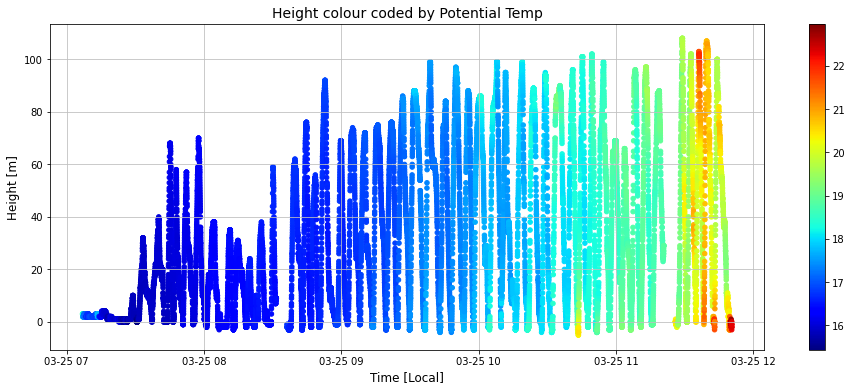

In [31]:
# Plot the data. The altitude was drifting during the experiment, due to the changing pressure.  
fig = plt.figure(figsize=(16,6))
ax = fig.add_subplot(111)

# scatter with colormap mapping to z value
sc = ax.scatter(data.index.values ,data['height_agl_m'].values,s=20,
                c=data['theta'].values, marker = 'o', cmap = cm.jet );
plt.colorbar(sc)

# Formatting the plot
ax.set_title("Height colour coded by Potential Temp",fontsize=14)
ax.set_xlabel("Time [Local]",fontsize=12)
ax.set_ylabel("Height [m]",fontsize=12)
ax.grid(True,linestyle='-',color='0.75')

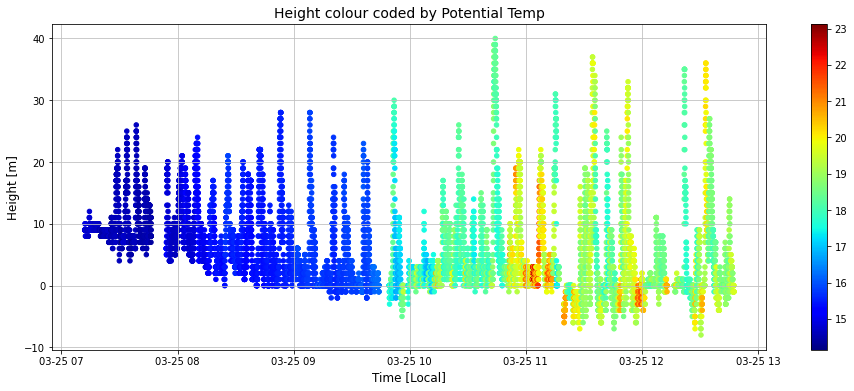

In [32]:
# Plot the data. The altitude was drifting during the experiment, due to the changing pressure.  
fig = plt.figure(figsize=(16,6))
ax = fig.add_subplot(111)

# scatter with colormap mapping to z value
sc = ax.scatter(data.index.values ,data['height_agl_m'].values,s=20,
                c=data['theta'].values, marker = 'o', cmap = cm.jet );
plt.colorbar(sc)

# Formatting the plot
ax.set_title("Height colour coded by Potential Temp",fontsize=14)
ax.set_xlabel("Time [Local]",fontsize=12)
ax.set_ylabel("Height [m]",fontsize=12)
ax.grid(True,linestyle='-',color='0.75')

## Height Correcting
There appears to be drift in the height - this needs to be corrected.

In [33]:
data

,utc_time,height_msl_m,height_agl_m,pressure,horizontal_speed_mps,heading_deg,temperature,rh,vertical_speed_mps,theta,datetimes_utc
datetimes_local,,,,,,,,,,,
2024-03-25 07:06:57,20:06:57,55,3,99968,,,18.70,86.15,,18.726716,2024-03-24 20:06:57
2024-03-25 07:06:59,20:06:59,55,3,99968,,,18.63,85.95,,18.656709,2024-03-24 20:06:59
2024-03-25 07:07:00,20:07:00,55,3,99969,,,18.58,86.00,,18.605870,2024-03-24 20:07:00
2024-03-25 07:07:01,20:07:01,55,3,99970,,,18.50,85.65,,18.525028,2024-03-24 20:07:01
2024-03-25 07:07:02,20:07:02,55,3,99971,,,18.40,85.10,,18.424186,2024-03-24 20:07:02
...,...,...,...,...,...,...,...,...,...,...,...
2024-03-25 11:50:34,00:50:34,49,-2,100042,1.10,119.60,22.28,69.60,-0.1,22.244523,2024-03-25 00:50:34
2024-03-25 11:50:35,00:50:35,48,-3,100050,0.70,95.80,22.29,69.70,-0.1,22.247766,2024-03-25 00:50:35
2024-03-25 11:50:36,00:50:36,49,-2,100039,0.55,96.90,22.38,69.30,0,22.347045,2024-03-25 00:50:36


In [37]:
import numpy as np
import pandas as pd

# Create an empty array to store corrected heights
height_corrected = np.full(len(data), np.nan)

# Get the first and last time values from the index
tstart = data.index[0]
tend_full = data.index[-1]

# Total number of minutes in the dataset
nmins = pd.Timedelta(tend_full - tstart).total_seconds() / 60.0

# Set time window length in minutes
window_length = 30
n_segments = int(nmins // window_length)

print(f"Correcting over {n_segments + 1} time blocks")

# Loop through each 15-minute block
for segment in range(n_segments + 1):
    
    # The start of this block
    tblock_end = tstart + pd.Timedelta(minutes=window_length)
    
    # Get the times in this block
    datetimes = data[(data.index >= tstart) & (data.index < tblock_end)].index
    # Find where i the array there are localed
    inds = [data.index.get_loc(dt) for dt in datetimes]
    heights_seg = data.loc[datetimes, 'height_msl_m'].values

    min_height = np.min(heights_seg)
    height_corrected[inds] = heights_seg - min_height

    print(f"Block {segment + 1}: {tstart.time()} – {tblock_end.time()}")

    # Advance to next time window
    tstart = tblock_end

# Add corrected heights to the DataFrame
data['height_corrected'] = height_corrected

Correcting over 10 time blocks
Block 1: 07:06:57 – 07:36:57
Block 2: 07:36:57 – 08:06:57
Block 3: 08:06:57 – 08:36:57
Block 4: 08:36:57 – 09:06:57
Block 5: 09:06:57 – 09:36:57
Block 6: 09:36:57 – 10:06:57
Block 7: 10:06:57 – 10:36:57
Block 8: 10:36:57 – 11:06:57
Block 9: 11:06:57 – 11:36:57
Block 10: 11:36:57 – 12:06:57


In [38]:
# Create an empty array to store corrected heights
height_corrected = np.full(len(data), np.nan)

# Get the first and last time values from the index
tstart = data.index[0]
tend_full = data.index[-1]

# Total number of minutes in the dataset
nmins = pd.Timedelta(tend_full - tstart).total_seconds() / 60.0

# Set time window length in minutes
window_length = 15
n_segments = int(nmins // window_length)

print(f"Correcting over {n_segments + 1} time blocks")

# Loop through each 15-minute block
for segment in range(n_segments + 1):
    
    # The end of this block
    tblock_end = tstart + pd.Timedelta(minutes=window_length)
    
    # Get the times in this block using boolean indexing
    mask = (data.index >= tstart) & (data.index < tblock_end)
    
    # Get the indices of the rows corresponding to these datetimes
    inds = np.where(mask)[0]
    
    # Extract the heights for this block, making sure the lengths match
    heights_seg = data.iloc[inds]['height_agl_m'].values
    
    # Adjust heights based on the minimum height in the segment
    min_height = np.min(heights_seg)
    
    # Assign the corrected heights to the correct indices
    height_corrected[inds] = heights_seg - min_height
    
    print(f"Block {segment + 1}: {tstart.time()} – {tblock_end.time()}")

    # Advance to the next time window
    tstart = tblock_end

# Add corrected heights to the DataFrame
data['height_corrected'] = height_corrected


Correcting over 23 time blocks
Block 1: 07:12:01 – 07:27:01
Block 2: 07:27:01 – 07:42:01
Block 3: 07:42:01 – 07:57:01
Block 4: 07:57:01 – 08:12:01
Block 5: 08:12:01 – 08:27:01
Block 6: 08:27:01 – 08:42:01
Block 7: 08:42:01 – 08:57:01
Block 8: 08:57:01 – 09:12:01
Block 9: 09:12:01 – 09:27:01
Block 10: 09:27:01 – 09:42:01
Block 11: 09:42:01 – 09:57:01
Block 12: 09:57:01 – 10:12:01
Block 13: 10:12:01 – 10:27:01
Block 14: 10:27:01 – 10:42:01
Block 15: 10:42:01 – 10:57:01
Block 16: 10:57:01 – 11:12:01
Block 17: 11:12:01 – 11:27:01
Block 18: 11:27:01 – 11:42:01
Block 19: 11:42:01 – 11:57:01
Block 20: 11:57:01 – 12:12:01
Block 21: 12:12:01 – 12:27:01
Block 22: 12:27:01 – 12:42:01
Block 23: 12:42:01 – 12:57:01


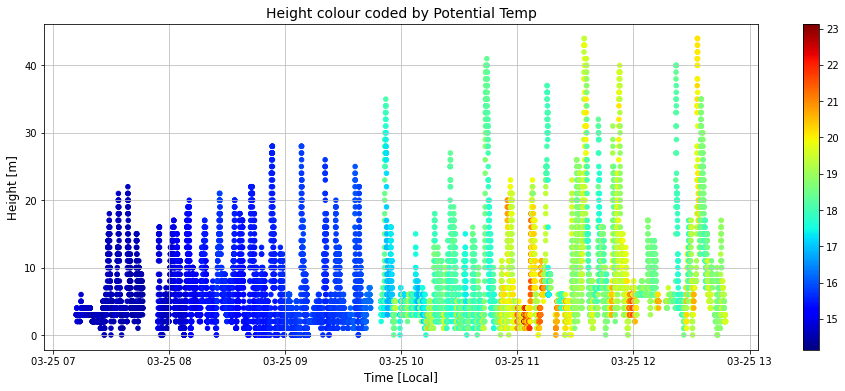

In [39]:
# Plot the data. The altitude was drifting during the experiment, due to the changing pressure.  
fig = plt.figure(figsize=(16,6))
ax = fig.add_subplot(111)

# scatter with colormap mapping to z value
sc = ax.scatter(data.index.values  ,data['height_corrected'].values,s=20,
                c=data['theta'].values, marker = 'o', cmap = cm.jet );
plt.colorbar(sc)

# Formatting the plot
ax.set_title("Height colour coded by Potential Temp",fontsize=14)
ax.set_xlabel("Time [Local]",fontsize=12)
ax.set_ylabel("Height [m]",fontsize=12)
ax.grid(True,linestyle='-',color='0.75')

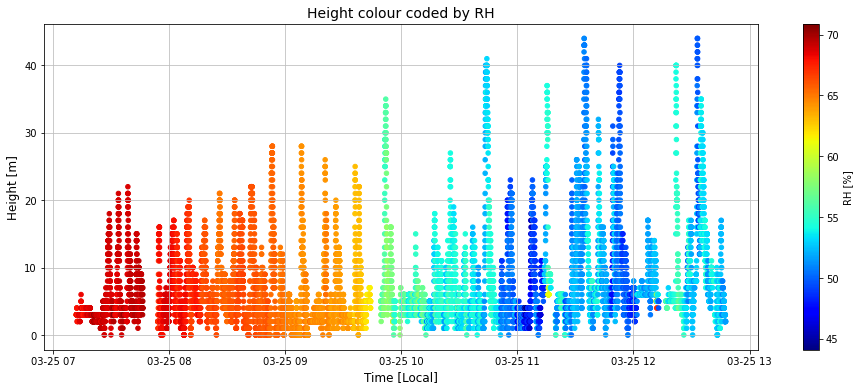

In [40]:
# Now do the same for Relative Humidity
fig = plt.figure(figsize=(16,6))
ax = fig.add_subplot(111)

# scatter with colormap mapping to z value
sc = ax.scatter(data.index.values, data['height_corrected'].values,s=20,
                c=data['rh'].values, marker = 'o', cmap = cm.jet );

cbar = plt.colorbar(sc)
cbar.set_label('RH [%]')

# Formatting the plot
ax.set_title("Height colour coded by RH",fontsize=14)
ax.set_xlabel("Time [Local]",fontsize=12)
ax.set_ylabel("Height [m]",fontsize=12)
ax.grid(True,linestyle='-',color='0.75')

## 30 Minute Averages
To smooth out the data a bit, we're going to average data from all heights into each 30 minute block of time

In [75]:
# Start time for analysis (local time)
start_time = pd.Timestamp('2024-03-25 07:00:00')

heights = range(0, 100, 5)

# Empty arrays to store data
average_rh_df = pd.DataFrame()
average_theta_df = pd.DataFrame()

# Loop over each 30-minute time block
for time_block in range(10):
    end_time = start_time + pd.Timedelta(minutes=30)

    # Select data within this time block
    block_data = data[(data.index.values > start_time) & (data.index.values < end_time)]

    # Loop over height from 0 to 100 m in steps of 5 m
    average_rh_list = []
    average_theta_list = []
    for bin_number, h in enumerate(heights):
        # Select data within this height bin
        bin_data = block_data[
            (block_data['height_corrected'] > h) & 
            (block_data['height_corrected'] < h + 5)
        ]
        
        # Calculate average theta and RH, ignoring missing values
        average_theta_list.append(
            bin_data['theta'].mean(skipna=True)
        )
        average_rh_list.append(
            bin_data['rh'].mean(skipna=True))
    
    average_rh_df[start_time] = average_rh_list
    average_theta_df[start_time] = average_theta_list


    print(f"Done with time block {time_block + 1}: {start_time.time()} – {end_time.time()}")
    start_time = end_time

average_rh_df['height'] = heights
average_rh_df = average_rh_df.set_index('height')

average_theta_df['height'] = heights
average_theta_df = average_theta_df.set_index('height')

Done with time block 1: 07:00:00 – 07:30:00
Done with time block 2: 07:30:00 – 08:00:00
Done with time block 3: 08:00:00 – 08:30:00
Done with time block 4: 08:30:00 – 09:00:00
Done with time block 5: 09:00:00 – 09:30:00
Done with time block 6: 09:30:00 – 10:00:00
Done with time block 7: 10:00:00 – 10:30:00
Done with time block 8: 10:30:00 – 11:00:00
Done with time block 9: 11:00:00 – 11:30:00
Done with time block 10: 11:30:00 – 12:00:00


In [76]:
average_rh_df

,2024-03-25 07:00:00,2024-03-25 07:30:00,2024-03-25 08:00:00,2024-03-25 08:30:00,2024-03-25 09:00:00,2024-03-25 09:30:00,2024-03-25 10:00:00,2024-03-25 10:30:00,2024-03-25 11:00:00,2024-03-25 11:30:00
height,,,,,,,,,,
0,68.709000,68.990084,67.258192,65.868005,64.508581,62.025637,54.502221,53.061693,49.825304,51.165979
5,68.789655,68.987027,66.867969,65.935849,64.489600,60.114754,54.977985,52.717358,52.581891,51.596234
10,68.855000,68.711413,66.854306,65.792800,64.179293,60.213710,54.080693,52.293069,49.733065,51.500667
15,68.937500,68.745455,66.484091,66.015278,64.277143,60.018182,53.814474,51.206579,49.496341,51.644762
20,NaN,68.780000,65.083333,66.009322,64.364706,61.523529,54.162500,50.934091,51.268182,51.649444
25,NaN,NaN,NaN,65.438636,64.312500,55.960000,54.187500,53.037500,54.483333,51.203571
30,NaN,NaN,NaN,NaN,NaN,56.084615,NaN,53.100000,54.637500,50.686957
35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.978261,54.333333,49.698387
40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53.150000,NaN,50.921429


In [68]:
# Create empty arrays to store average values
# 10 time blocks (half-hour), 20 height bins (0–100 m, 5 m each)
average_theta = np.full((10, 20), np.nan)
average_rh = np.full((10, 20), np.nan)

# Start time for analysis (local time)
start_time = pd.Timestamp('2024-03-25 07:00:00')

# Loop over each 30-minute time block
for time_block in range(10):
    end_time = start_time + pd.Timedelta(minutes=30)

    # Select data within this time block
    block_data = data[(data.index.values > start_time) & (data.index.values < end_time)]

    # Loop over height from 0 to 100 m in steps of 5 m
    for bin_number, h in enumerate(range(0, 100, 5)):
        # Select data within this height bin
        bin_data = block_data[
            (block_data['height_corrected'] > h) & 
            (block_data['height_corrected'] < h + 5)
        ]

        # Calculate average theta and RH, ignoring missing values
        average_theta[time_block, bin_number] = bin_data['theta'].mean(skipna=True)
        average_rh[time_block, bin_number] = bin_data['rh'].mean(skipna=True)

    print(f"Done with time block {time_block + 1}: {start_time.time()} – {end_time.time()}")
    start_time = end_time

Done with time block 1: 07:00:00 – 07:30:00
Done with time block 2: 07:30:00 – 08:00:00
Done with time block 3: 08:00:00 – 08:30:00
Done with time block 4: 08:30:00 – 09:00:00
Done with time block 5: 09:00:00 – 09:30:00
Done with time block 6: 09:30:00 – 10:00:00
Done with time block 7: 10:00:00 – 10:30:00
Done with time block 8: 10:30:00 – 11:00:00
Done with time block 9: 11:00:00 – 11:30:00
Done with time block 10: 11:30:00 – 12:00:00


In [69]:
average_theta

array([[14.68154391, 14.63467771, 14.61952242, 14.64183458,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan],
       [14.61759196, 14.57486368, 14.64349995, 14.6725256 , 14.6622252 ,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan],
       [15.11790636, 15.23022447, 15.27255016, 15.39631434, 15.8864034 ,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan],
       [15.44416415, 15.44119856, 15.4960067 , 15.47823244, 15.50175914,
        15.57944275,         nan,         nan,  

# Dataset 2: Hand held anemometer data from surface 
If we manage to get this, we'll provide lines of code


In [45]:
## Next read the surface data from the automatic kestral measurements mounted on the side of the cricket pitch
kestrel_auto = pd.read_csv('WEATHER_-_2674753_Mar_31_2025_2_57_00_PM.csv', skiprows=3)

In [46]:
new_column_names = {
    'FORMATTED DATE_TIME' : 'datetime'
}
kestrel_auto = (kestrel_auto
         .rename(columns=new_column_names) # Rename the columns
         ) 


In [47]:
kestrel_auto.datetime = pd.to_datetime(kestrel_auto.datetime.values)

In [48]:
kestrel_auto

,datetime,Temperature_C,WetBulbTemp_C,RH_pct,Pressure_hPa,Altitude_m,StationPressure_hPa,WindSpeed_kmperhour,HeatIndex_C,DewPoint_C,DensityAltitude_m,Crosswind_kmperhr,Headwind_kmperhr,Wind_Direction_degrees,Direction_True_degrees,WindChill_C
0,2025-03-31 07:15:00,15.4,11.9,66.8,1016.5,-30,1016.6,6.4,14.6,9.3,26,6.2,-1.5,106,106,15.2
1,2025-03-31 07:16:00,15.5,12.0,66.8,1016.5,-29,1016.5,2.1,14.6,9.3,29,2.0,0.5,76,76,15.4
2,2025-03-31 07:17:00,15.4,11.9,66.8,1016.5,-29,1016.5,9.9,14.5,9.2,25,9.5,-3.0,111,112,14.5
3,2025-03-31 07:18:00,15.3,11.8,66.9,1016.5,-29,1016.6,4.8,14.5,9.2,23,3.6,-3.2,130,131,15.3
4,2025-03-31 07:19:00,15.4,11.9,66.8,1016.7,-30,1016.6,15.5,14.5,9.2,24,5.9,-14.3,188,188,13.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,2025-03-31 12:55:00,21.6,14.6,46.7,1017.0,3,1017.1,5.1,21.0,9.7,241,2.7,-4.3,148,148,21.5
341,2025-03-31 12:56:00,21.7,14.7,46.7,1017.2,2,1017.2,1.2,21.1,9.8,245,0.7,-1.0,144,144,21.7
342,2025-03-31 12:57:00,22.3,15.0,46.0,1017.0,2,1017.1,1.4,21.6,10.1,268,0.6,-1.3,154,155,22.3
343,2025-03-31 12:58:00,22.6,15.2,45.5,1017.2,2,1017.3,1.5,21.9,10.2,277,0.3,-1.4,166,167,22.6


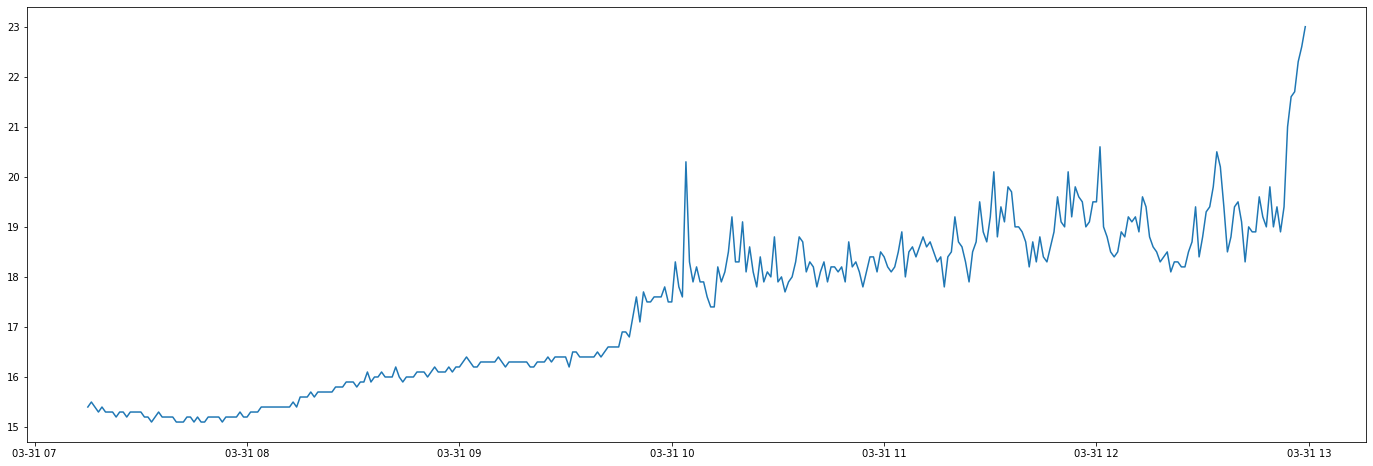

In [50]:
plt.figure(figsize=(24,8))
plt.plot(kestrel_auto.datetime, kestrel_auto.Temperature_C)

# Dataset 3: Surface Data
Next read the surface data collected on the sports ground

In [12]:
## Next read the surface 10 minute obs (edit this depending on how it ends up getting typed up)
#data3 = pd.read_csv('Surface_data_10min.csv', parse_dates=[['Date', 'Time']])
surface_data = pd.read_csv('Surface_data_10min_2023_for2025assignment.csv', parse_dates=[['Date', 'Time']])
#surface_data = pd.read_csv('Surface_data_10min_2025.csv')

surface_data.head()

,Date_Time,Clouds_oktas,Clouds_descr,Weather_elements,Pressure,Temp,Dewpoint,RH,Wind_speed
0,2023-03-28 07:20:00,8.0,full cloud cover mildly dark,dew on grass,1007.8,17.8,15.8,85.6,0.0
1,2023-03-28 07:30:00,6.0,ditto with cloud dispersal,dew on grass,1007.9,17.3,16.7,95.4,0.0
2,2023-03-28 07:40:00,6.0,ditto,NaN,1008.0,16.6,16.1,98.7,0.0
3,2023-03-28 07:50:00,8.0,black band aroundnwest.lighter elsewhere,ditto,1008.1,16.8,15.7,94.6,0.0
4,2023-03-28 08:00:00,8.0,ditto,ditto,1008.2,16.7,15.8,93.7,0.0


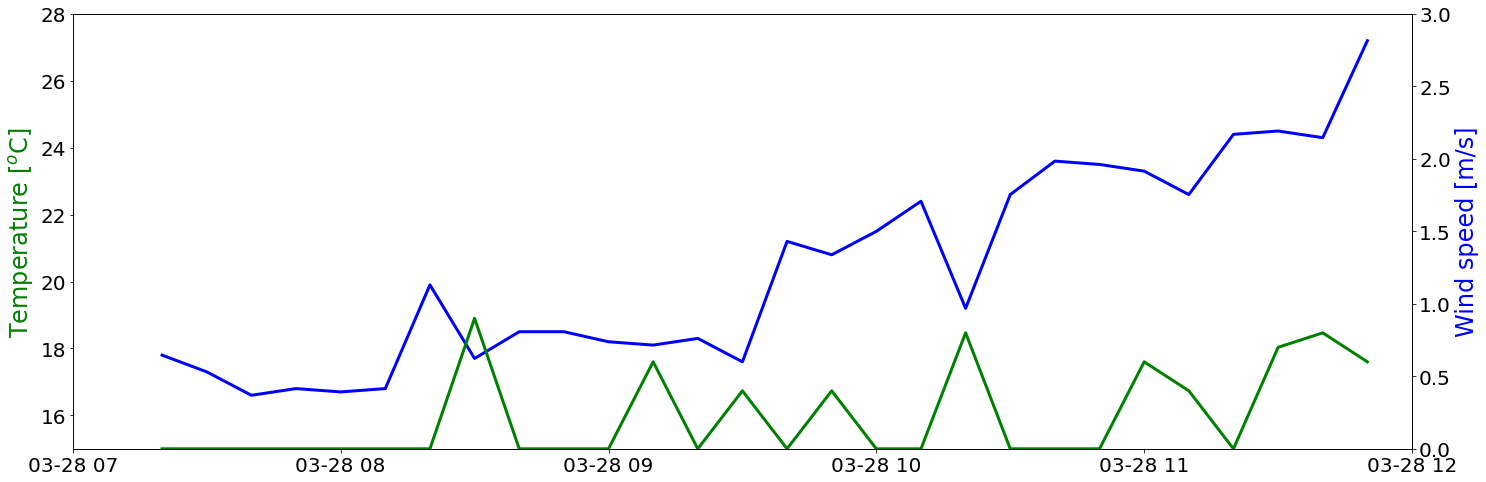

In [248]:
fig, ax1 = plt.subplots(figsize=(24, 8))

ax2 = ax1.twinx()

tstart = datetime.datetime(2023, 3, 28, 7, 0, 0)
tend = datetime.datetime(2023, 3, 28, 12, 0, 0)
ax1.plot(pd.to_datetime(surface_data.Date_Time), surface_data.Temp, linewidth=3, color='b')
ax2.plot(pd.to_datetime(surface_data.Date_Time), surface_data.Wind_speed, linewidth=3, color='g')

ax1.set_xlim([tstart, tend])
ax2.set_xlim([tstart, tend])

ax1.set_ylim([15, 28])
ax2.set_ylim([0,3])

ax1.set_ylabel('Temperature [$^o$C]', color='g', fontsize=24)
ax2.set_ylabel('Wind speed [m/s]', color='b', fontsize=24)

ax1.tick_params(labelsize=20)
ax2.tick_params(labelsize=20)


# Dataset 4: Data from Redmond Barry Building 
Next read the data from the weather station at the top of Redmond Barry (~50 metres)

In [2]:
# The first 6 rows are metadata
redmond_barry_data_2023 = pd.read_csv('2023_AQM65 04112021-856 Data Export.csv', skiprows=6)

# The first row is just metadata - select rows 1 onwards (:) and all columns (:)
redmond_barry_data_2023 =redmond_barry_data_2023.iloc[1:, :] 

In [3]:
# The first 6 rows are metadata
redmond_barry_data_2025 = pd.read_csv('2025_AQM65 04112021-856 Data Export.csv', skiprows=6)

# The first row is just metadata - select rows 1 onwards (:) and all columns (:)
redmond_barry_data_2025 =redmond_barry_data_2025.iloc[1:, :] 

In [4]:
# The first row is just metadata - select rows 1 onwards (:) and all columns (:)
redmond_barry_data_2025

,Time,CO (ppm),NO2 (ppm),NOx (ppm),O3 (ppm),PM2.5 (µg/m³),Ext BC (ng/m³),Ext UVPM (ng/m³),Ext BC(Blue) (ng/m³),Ext BC(Green) (ng/m³),Ext BC(Red) (ng/m³),WS (m/s),WD (°),PRESS (hPa),Pyrano (W/m²),AIR T (°C),AIR RH (%),ITEMP (°C),TEMP (°C),RH (%)
1,2024/12/14 00:10:00,0.219,0.007,0.002,0.030,1.70,257.9,245.0,174.8,203.8,262.7,2.32,136.3,998.9,0.6,15.5,76.0,30.0,16.06,72.6
2,2024/12/14 00:20:00,0.215,0.005,0.001,0.030,1.78,291.6,372.2,403.2,333.5,363.1,2.63,148.7,998.8,0.8,15.5,76.0,30.0,15.97,72.8
3,2024/12/14 00:30:00,0.209,0.004,0.001,0.030,1.80,86.4,279.2,266.4,206.7,216.7,2.44,148.1,998.7,0.6,15.4,75.8,30.0,15.90,72.5
4,2024/12/14 00:40:00,0.208,0.003,0.001,0.030,1.82,164.7,210.1,163.1,125.2,188.0,2.68,148.3,998.7,0.4,15.4,75.1,29.9,15.85,72.1
5,2024/12/14 00:50:00,0.210,0.006,0.002,0.029,1.84,103.2,219.3,163.9,200.4,180.9,2.57,144.4,998.6,0.6,15.4,75.0,30.0,15.83,72.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15491,2025/03/31 13:50:00,0.195,0.003,0.001,0.038,2.49,195.9,271.9,176.7,133.5,145.6,4.39,154.6,1007.3,355.9,19.5,50.8,30.0,21.43,43.9
15492,2025/03/31 14:00:00,0.193,0.003,0.001,0.037,2.37,215.9,279.9,279.6,395.6,234.2,3.37,150.9,1007.2,356.1,19.6,50.0,30.0,21.28,43.9
15493,2025/03/31 14:10:00,0.192,0.004,0.001,0.038,2.43,352.6,383.7,318.2,288.3,237.3,5.08,158.7,1007.0,471.0,19.7,50.5,30.0,21.56,43.9
15494,2025/03/31 14:20:00,0.186,0.001,0.000,0.039,2.27,160.6,299.4,341.8,262.4,336.7,5.52,153.0,1006.9,408.2,19.4,51.2,30.0,21.30,44.3


In [5]:
# Rename some columns
new_column_names = {
    # Format is 
    # Old name : new name
    'CO (ppm)': 'CO_ppm',
    'NO2 (ppm)': 'NO2_ppm',
    'NOx (ppm)': 'NOx_ppm',
    'O3 (ppm)': 'O3_ppm',
    'PM2.5 (µg/m³)': 'PM2p5_microgm3',
    'WS (m/s)': 'WS_ms',
    'WD (°)': 'WD_degrees',
    'PRESS (hPa)': 'P_hpa',
    'Pyrano (W/m²)': 'Pyr_wm2',
    'AIR T (°C)': 'T_C',
    'AIR RH (%)':  'RH_pct'
}

In [6]:
redmond_barry_data_2023 = (redmond_barry_data_2023
         .rename(columns=new_column_names) # Rename the columns
         .drop(columns=['Inlet', 'Leq (dBA)', 'ITEMP (°C)', 'TEMP (°C)', 'RH (%)']) # Remove these columns
        )

In [7]:
redmond_barry_data_2025 = (redmond_barry_data_2025
         .rename(columns=new_column_names) # Rename the columns
         .drop(columns=['ITEMP (°C)', 'TEMP (°C)', 'RH (%)']) # Remove these columns
        )

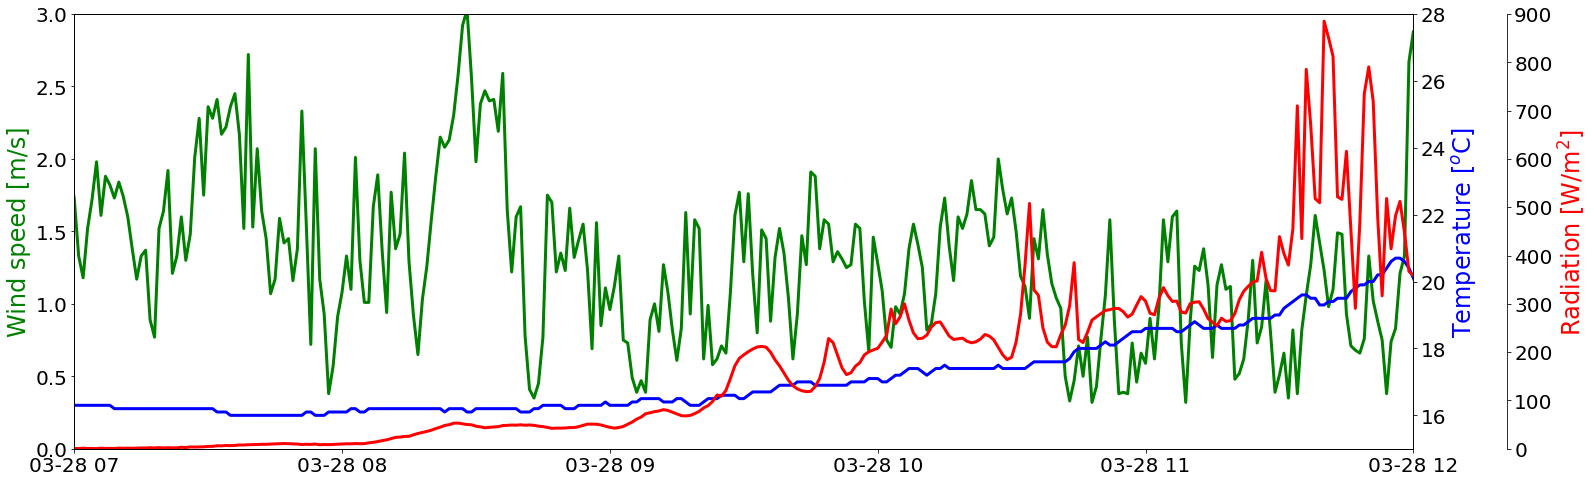

In [207]:
# Here we plot the time series of meteorological data from the top of the Redmond Barry Building
tstart = datetime.datetime(2023, 3, 28, 7, 0, 0)
tend = datetime.datetime(2023, 3, 28, 12, 0, 0)

fig, ax1 = plt.subplots(figsize=(24, 8))

ax2 = ax1.twinx()
ax3 = ax1.twinx()

ax3.spines["right"].set_position(("axes", 1.07))

ax1.plot(pd.to_datetime(redmond_barry_data_2023.Time), redmond_barry_data_2023.WS_ms, 'g-', linewidth=3)
ax2.plot(pd.to_datetime(redmond_barry_data_2023.Time), redmond_barry_data_2023.T_C, 'b-', linewidth=3)
ax3.plot(pd.to_datetime(redmond_barry_data_2023.Time), redmond_barry_data_2023.Pyr_wm2, 'r-', linewidth=3)

ax1.set_xlim([tstart, tend])
ax2.set_xlim([tstart, tend])
ax3.set_xlim([tstart, tend])

ax2.set_ylim([15, 28])
ax1.set_ylim([0,3])
ax3.set_ylim([0,900])


ax1.set_ylabel('Wind speed [m/s]', color='g', fontsize=24)
ax2.set_ylabel('Temperature [$^o$C]', color='b', fontsize=24)
ax3.set_ylabel('Radiation [W/m$^2$]', color='r', fontsize=24)

ax1.tick_params(labelsize=20)
ax2.tick_params(labelsize=20)
ax3.tick_params(labelsize=20)

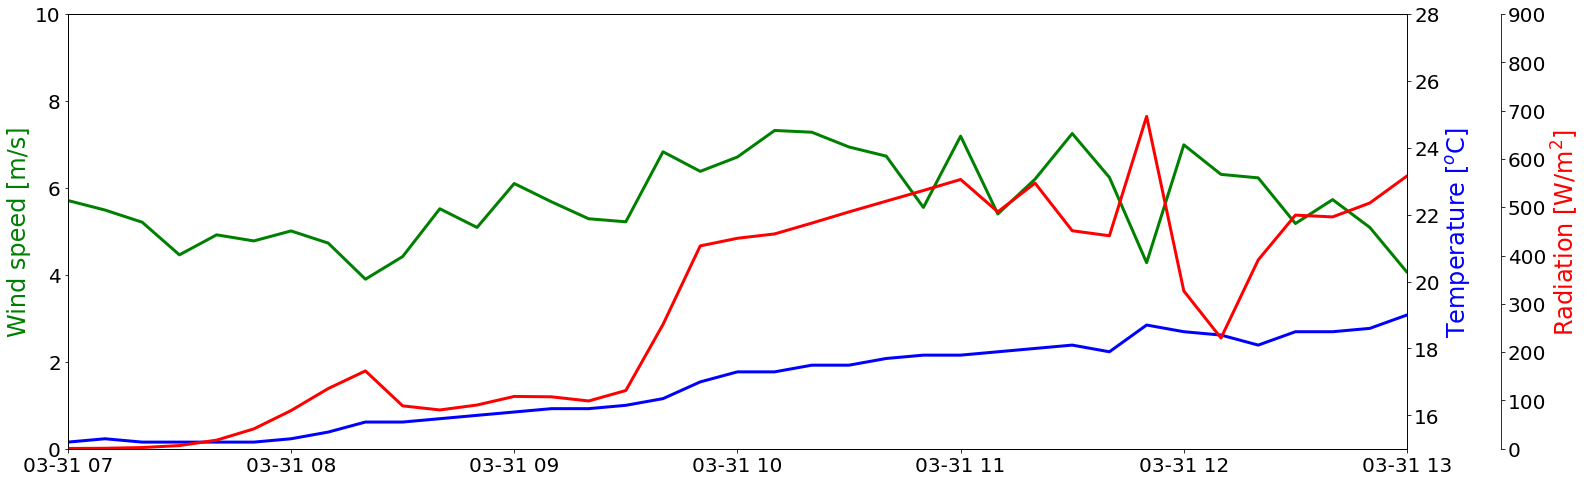

In [9]:
# Here we plot the time series of meteorological data from the top of the Redmond Barry Building
tstart = datetime.datetime(2025, 3, 31, 7, 0, 0)
tend = datetime.datetime(2025, 3, 31, 13, 0, 0)

fig, ax1 = plt.subplots(figsize=(24, 8))

ax2 = ax1.twinx()
ax3 = ax1.twinx()

ax3.spines["right"].set_position(("axes", 1.07))

ax1.plot(pd.to_datetime(redmond_barry_data_2025.Time), redmond_barry_data_2025.WS_ms, 'g-', linewidth=3)
ax2.plot(pd.to_datetime(redmond_barry_data_2025.Time), redmond_barry_data_2025.T_C, 'b-', linewidth=3)
ax3.plot(pd.to_datetime(redmond_barry_data_2025.Time), redmond_barry_data_2025.Pyr_wm2, 'r-', linewidth=3)

ax1.set_xlim([tstart, tend])
ax2.set_xlim([tstart, tend])
ax3.set_xlim([tstart, tend])

ax2.set_ylim([15, 28])
ax1.set_ylim([0,10])
ax3.set_ylim([0,900])


ax1.set_ylabel('Wind speed [m/s]', color='g', fontsize=24)
ax2.set_ylabel('Temperature [$^o$C]', color='b', fontsize=24)
ax3.set_ylabel('Radiation [W/m$^2$]', color='r', fontsize=24)

ax1.tick_params(labelsize=20)
ax2.tick_params(labelsize=20)
ax3.tick_params(labelsize=20)